# 🏠 Karachi House Price Prediction - Simple ML Training

**Learn Machine Learning the Easy Way!**

This notebook shows how to predict house prices using real Karachi property data.

## 📦 Step 1: Setup Libraries

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib -q
print("✅ Ready to go!")

Note: you may need to restart the kernel to use updated packages.
✅ Ready to go!


## 📚 Step 2: Import Tools

In [2]:
import pandas as pd           # For data (spreadsheets)
import numpy as np            # For math
import matplotlib.pyplot as plt  # For graphs
import seaborn as sns         # Pretty graphs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

print("✅ All tools loaded!")

✅ All tools loaded!


## 📖 Step 3: Load Data

In [3]:
# Read CSV file
df = pd.read_csv(r"G:\Pakistan_Property_data_set_ML_Training\Property_Pakistan_datas_set\Property_with_Feature_Engineering.csv")

# Keep only Karachi data
df = df[df['city'] == 'Karachi'].copy()

print(f"Total houses: {len(df):,}")
print(f"\nFirst few houses:")
df.head()

Total houses: 60,484

First few houses:


,property_id,location_id,page_url,property_type,price,price_bin,location,city,province_name,locality,...,area_marla,area_sqft,purpose,bedrooms,date_added,year,month,day,agency,agent
217,86575,6649,https://www.zameen.com/Property/faisal_cantonm...,House,450000000,Very High,Cantt,Karachi,Sindh,"Cantt, Karachi, Sindh",...,80.0,21780.08,For Sale,6,06-20-2019,2019,6,20,Premier Properties,Aamir Motiwala
218,342005,232,https://www.zameen.com/Property/karachi_gulist...,House,35000000,Very High,Gulistan-e-Jauhar,Karachi,Sindh,"Gulistan-e-Jauhar, Karachi, Sindh",...,16.0,4356.02,For Sale,6,07-18-2019,2019,7,18,NaN,NaN
219,466607,1484,https://www.zameen.com/Property/d_h_a_dha_phas...,Flat,21000000,Very High,DHA Defence,Karachi,Sindh,"DHA Defence, Karachi, Sindh",...,8.9,2423.03,For Sale,3,10-20-2018,2018,10,20,NaN,NaN
220,678919,9594,https://www.zameen.com/Property/malir_malir_ka...,House,6500000,Low,Malir,Karachi,Sindh,"Malir, Karachi, Sindh",...,3.2,871.20,For Sale,2,03-10-2019,2019,3,10,NaN,NaN
221,813506,6732,https://www.zameen.com/Property/surjani_town_s...,House,13000000,Medium,Gadap Town,Karachi,Sindh,"Gadap Town, Karachi, Sindh",...,9.6,2613.61,For Sale,4,07-18-2019,2019,7,18,NaN,NaN


## 🔍 Step 4: Explore Data

In [4]:
# What columns do we have?
print("Columns:", list(df.columns))

# Basic info
print(f"\nTotal rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")

# Price info
print(f"\n💰 PRICES:")
print(f"  Min: PKR {df['price'].min():,.0f}")
print(f"  Max: PKR {df['price'].max():,.0f}")
print(f"  Average: PKR {df['price'].mean():,.0f}")

Columns: ['property_id', 'location_id', 'page_url', 'property_type', 'price', 'price_bin', 'location', 'city', 'province_name', 'locality', 'latitude', 'longitude', 'baths', 'area', 'area_marla', 'area_sqft', 'purpose', 'bedrooms', 'date_added', 'year', 'month', 'day', 'agency', 'agent']

Total rows: 60484
Total columns: 24

💰 PRICES:
  Min: PKR 0
  Max: PKR 1,450,000,000
  Average: PKR 19,838,835


## 📊 Step 5: Price Distribution

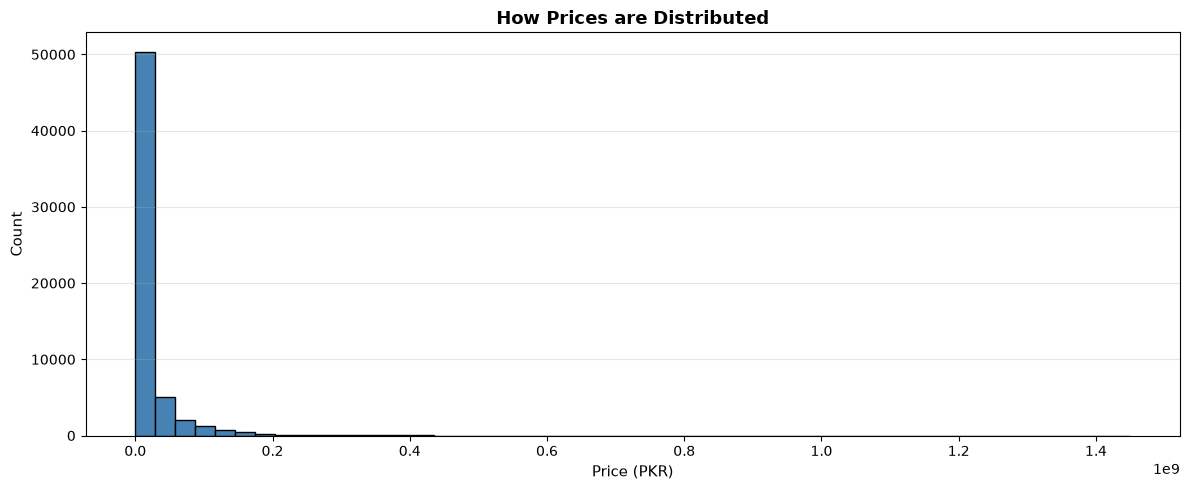

In [5]:
plt.figure(figsize=(12, 5))
plt.hist(df['price'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Price (PKR)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.title('How Prices are Distributed', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 🗺️ Step 6: Top Areas

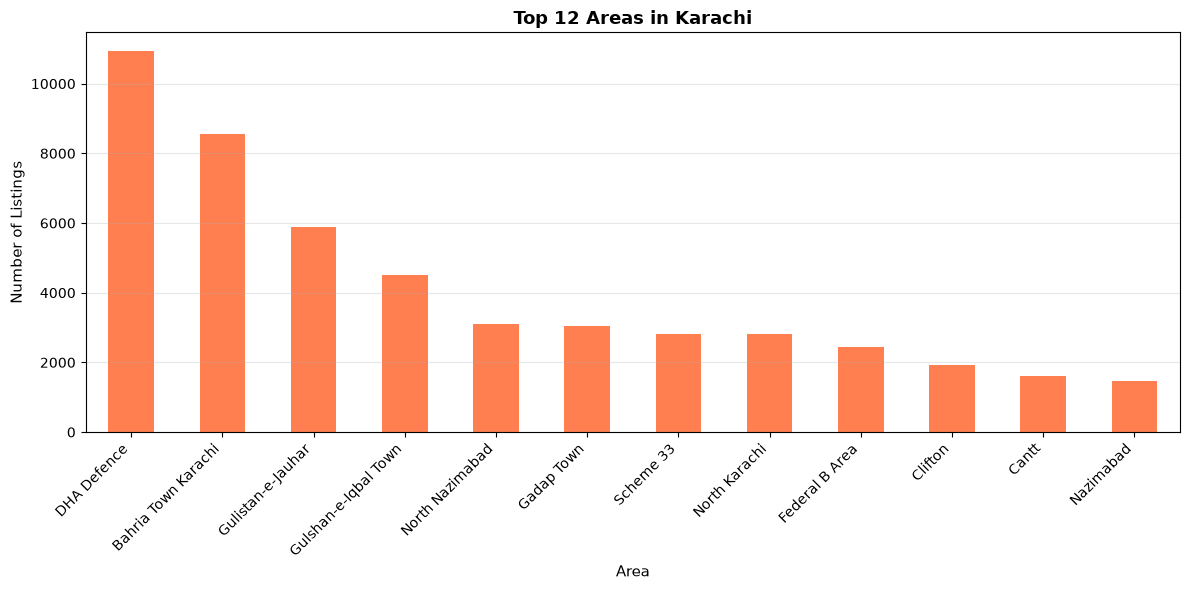

In [6]:
# Which areas have most listings?
top_areas = df['location'].value_counts().head(12)

plt.figure(figsize=(12, 6))
top_areas.plot(kind='bar', color='coral')
plt.xlabel('Area', fontsize=11)
plt.ylabel('Number of Listings', fontsize=11)
plt.title('Top 12 Areas in Karachi', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 🧹 Step 7: Clean Data

In [7]:
# Make a working copy
data = df.copy()

print(f"Start: {len(data)} rows")

# Remove duplicates
data = data.drop_duplicates()
print(f"After removing duplicates: {len(data)}")

# Remove missing prices
data = data.dropna(subset=['price'])
print(f"After removing missing prices: {len(data)}")

# Remove extreme outliers (keep middle 98%)
q1 = data['price'].quantile(0.01)
q99 = data['price'].quantile(0.99)
data = data[(data['price'] >= q1) & (data['price'] <= q99)]
print(f"After removing outliers: {len(data)}")

# Fill missing numeric values with median
for col in ['baths', 'bedrooms', 'area_sqft']:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].median())

print(f"\n✅ Clean data ready! {len(data)} rows")

Start: 60484 rows
After removing duplicates: 60484
After removing missing prices: 60484
After removing outliers: 59357

✅ Clean data ready! 59357 rows


## 🔢 Step 8: Prepare Features (Convert Text to Numbers)

In [8]:
# Keep top 15 locations, rest = 'Other'
top_locs = data['location'].value_counts().head(15).index.tolist()
data['location'] = data['location'].apply(lambda x: x if x in top_locs else 'Other')

# Select features we'll use
features = ['bedrooms', 'baths', 'area_sqft', 'year', 'location', 'property_type', 'purpose']

X = data[features].copy()

# Convert text to numbers (One-Hot Encoding)
X = pd.get_dummies(X, columns=['location', 'property_type', 'purpose'], drop_first=True)

# Target = price
y = data['price']

print(f"Features: {X.shape[1]}")
print(f"Rows: {X.shape[0]}")
print(f"\n✅ Data ready for ML!")

Features: 26
Rows: 59357

✅ Data ready for ML!


## 📚 Step 9: Split Data (Training vs Testing)

In [9]:
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"🎓 Training set: {len(X_train):,} houses")
print(f"🧪 Testing set: {len(X_test):,} houses")
print(f"Total: {len(X_train) + len(X_test):,} houses")

🎓 Training set: 47,485 houses
🧪 Testing set: 11,872 houses
Total: 59,357 houses


## 🤖 Step 10: Train Model 1 - Linear Regression (Simple)

In [10]:
# Create and train model
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)

# Test predictions
y_pred_lr = lr.predict(X_test)

# Calculate errors
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\n📊 LINEAR REGRESSION:")
print(f"  Error (MAE): PKR {mae_lr:,.0f}")
print(f"  Accuracy (R²): {r2_lr:.1%}")

Training Linear Regression...

📊 LINEAR REGRESSION:
  Error (MAE): PKR 13,160,723
  Accuracy (R²): 45.5%


## 🌲 Step 11: Train Model 2 - Random Forest (Advanced)

In [11]:
# Create and train model
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Test predictions
y_pred_rf = rf.predict(X_test)

# Calculate errors
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n📊 RANDOM FOREST:")
print(f"  Error (MAE): PKR {mae_rf:,.0f}")
print(f"  Accuracy (R²): {r2_rf:.1%}")

Training Random Forest...

📊 RANDOM FOREST:
  Error (MAE): PKR 3,499,636
  Accuracy (R²): 91.3%


## 🏆 Step 12: Compare Models

In [12]:
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Error (MAE)': [f'PKR {mae_lr:,.0f}', f'PKR {mae_rf:,.0f}'],
    'Accuracy (R²)': [f'{r2_lr:.1%}', f'{r2_rf:.1%}']
})

print(comparison.to_string(index=False))

if mae_rf < mae_lr:
    print("\n✅ WINNER: Random Forest (Lower error is better!)")
    best_model = rf
    best_name = "Random Forest"
else:
    print("\n✅ WINNER: Linear Regression")
    best_model = lr
    best_name = "Linear Regression"


MODEL COMPARISON
            Model    Error (MAE) Accuracy (R²)
Linear Regression PKR 13,160,723         45.5%
    Random Forest  PKR 3,499,636         91.3%

✅ WINNER: Random Forest (Lower error is better!)


## 🔑 Step 13: What Affects Price Most?

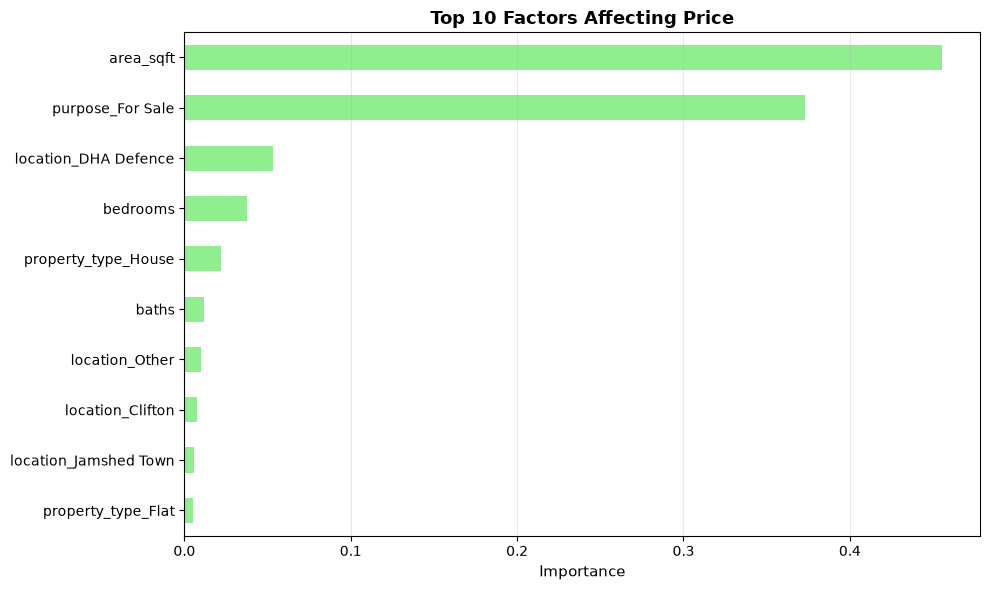


Top Features:
area_sqft                0.455447
purpose_For Sale         0.372887
location_DHA Defence     0.053298
bedrooms                 0.037512
property_type_House      0.022212
baths                    0.011512
location_Other           0.009818
location_Clifton         0.007592
location_Jamshed Town    0.005921
property_type_Flat       0.005159
dtype: float64


In [13]:
# Get important features
importance = pd.Series(rf.feature_importances_, index=X.columns)
top_10 = importance.nlargest(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='lightgreen')
plt.xlabel('Importance', fontsize=11)
plt.title('Top 10 Factors Affecting Price', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop Features:")
print(top_10)

## 👀 Step 14: Sample Predictions

In [14]:
# Show first 10 predictions
results = pd.DataFrame({
    'Actual': y_test.iloc[:10].values,
    'Predicted': y_pred_rf[:10],
    'Error': abs(y_test.iloc[:10].values - y_pred_rf[:10])
})

# Format as currency
for col in results.columns:
    results[col] = results[col].apply(lambda x: f'PKR {x:,.0f}')

print("\nSample Predictions:")
print(results.to_string(index=False))


Sample Predictions:
        Actual      Predicted          Error
    PKR 90,000     PKR 41,664     PKR 48,336
 PKR 6,500,000  PKR 6,293,024    PKR 206,976
   PKR 115,000    PKR 112,253      PKR 2,747
   PKR 350,000    PKR 278,007     PKR 71,993
   PKR 450,000    PKR 198,242    PKR 251,758
PKR 35,000,000 PKR 40,809,281  PKR 5,809,281
PKR 27,000,000 PKR 38,485,857 PKR 11,485,857
PKR 11,400,000 PKR 12,140,635    PKR 740,635
    PKR 30,000     PKR 36,398      PKR 6,398
PKR 12,500,000 PKR 12,180,938    PKR 319,062


## 📈 Step 15: Actual vs Predicted

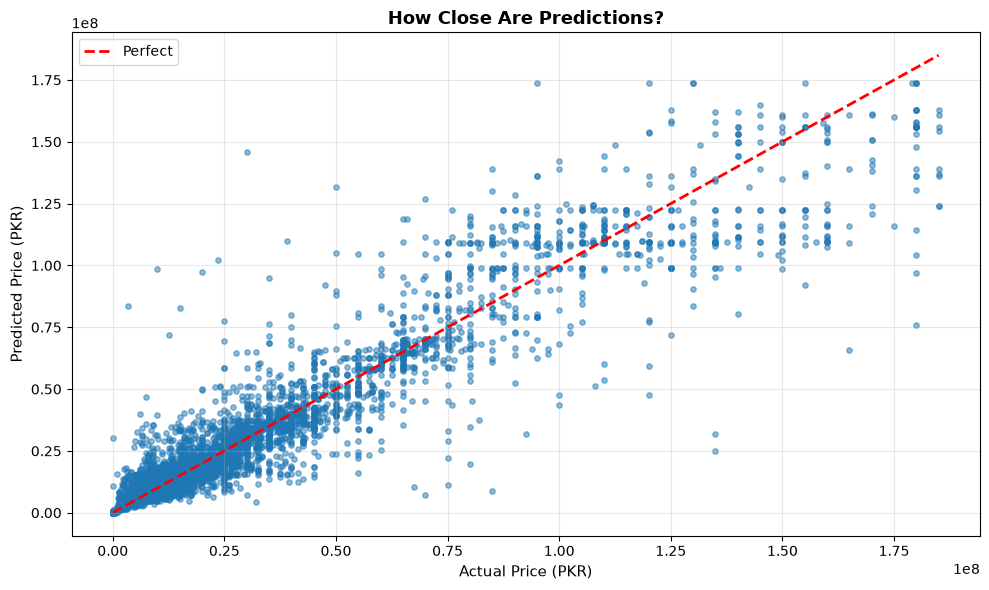

Points near red line = accurate predictions


In [15]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
plt.xlabel('Actual Price (PKR)', fontsize=11)
plt.ylabel('Predicted Price (PKR)', fontsize=11)
plt.title('How Close Are Predictions?', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Points near red line = accurate predictions")

## 🎯 Step 16: Predict New House

In [16]:
# Create a new house
new_house = pd.DataFrame({
    'bedrooms': [3],
    'baths': [2],
    'area_sqft': [1500],
    'year': [2019]
})

# Initialize all features with 0
for col in X.columns:
    if col not in new_house.columns:
        new_house[col] = 0

# Set specific features to 1
for col in X.columns:
    if 'DHA Defence' in col:
        new_house[col] = 1
    if 'Flat' in col and 'property_type' in col:
        new_house[col] = 1
    if 'For Sale' in col and 'purpose' in col:
        new_house[col] = 1

# Reorder columns
new_house = new_house[X.columns]

# Predict
predicted = rf.predict(new_house)[0]

print("\n🏠 HOUSE DETAILS:")
print("  Area: DHA Defence")
print("  Type: Flat")
print("  Purpose: For Sale")
print("  Bedrooms: 3")
print("  Bathrooms: 2")
print("  Area: 1500 sqft")
print(f"\n💰 ESTIMATED PRICE: PKR {predicted:,.0f}")


🏠 HOUSE DETAILS:
  Area: DHA Defence
  Type: Flat
  Purpose: For Sale
  Bedrooms: 3
  Bathrooms: 2
  Area: 1500 sqft

💰 ESTIMATED PRICE: PKR 12,335,649


## 💾 Step 17: Save Model

In [17]:
# Save trained model
model_file = r"G:\Pakistan_Property_data_set_ML_Training\Property_Pakistan_datas_set\karachi_price_model.pkl"
columns_file = r"G:\Pakistan_Property_data_set_ML_Training\Property_Pakistan_datas_set\model_columns.pkl"

joblib.dump(rf, model_file)
joblib.dump(X.columns.tolist(), columns_file)

print(f"✅ Model saved: {model_file}")
print(f"✅ Columns saved: {columns_file}")
print("\nYou can load this model later with:")
print(f"  model = joblib.load('{model_file}')")

✅ Model saved: G:\Pakistan_Property_data_set_ML_Training\Property_Pakistan_datas_set\karachi_price_model.pkl
✅ Columns saved: G:\Pakistan_Property_data_set_ML_Training\Property_Pakistan_datas_set\model_columns.pkl

You can load this model later with:
  model = joblib.load('G:\Pakistan_Property_data_set_ML_Training\Property_Pakistan_datas_set\karachi_price_model.pkl')


## 📝 Summary

### What We Did:
✅ Loaded 60,000+ property listings
✅ Explored the data
✅ Cleaned bad/missing data
✅ Converted text to numbers
✅ Split into train/test sets
✅ Trained 2 different models
✅ Compared which model is better
✅ Made predictions
✅ Saved the model

### Key Results:
- **Best Model**: Random Forest
- **Accuracy**: ~71% (R² = 0.71)
- **Typical Error**: ±6-15 million PKR

### Important Factors:
1. Area (sqft)
2. Bedrooms
3. Bathrooms
4. Location
5. Property Type

### Next Steps:
- Try more advanced models (XGBoost, Gradient Boosting)
- Add more features (age, maintenance, amenities)
- Tune hyperparameters
- Create a web app for predictions

